<a href="https://colab.research.google.com/github/ArtNizh/ML/blob/main/ML_%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0%D1%8F_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 4. Математика CNN и FGSM-атаки

**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам Лекции 3**

**Формат:** индивидуально

**Среда:** Python, PyTorch, torchvision

## Цель работы
Закрепить математический аппарат свёртки и рецептивного поля, а также научиться конструировать и анализировать evasion-атаку методом Fast Gradient Sign Method (FGSM) на реальной свёрточной сети.

## Результаты обучения
После выполнения работы вы должны уметь:
- рассчитывать размер выходной карты признаков и рецептивное поле для произвольной конфигурации свёрточных слоёв;
- объяснять архитектурные решения LeNet, AlexNet, VGG, ResNet и их мотивацию;
- реализовывать FGSM-атаку по формуле $ x_{adv} = x + \epsilon \cdot \text{sign}(\nabla_x J(\theta, x, y)) $;
- строить и интерпретировать зависимость Attack Success Rate от бюджета $\epsilon$;
- применять adversarial training как базовую меру защиты.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.


## 0. Подготовка окружения

**Тензор** — это многомерный массив чисел. Изображение MNIST — тензор формы [batch, channels, height, width]. Свёрточная сеть работает именно с такими четырёхмерными тензорами.  
batch - сколько картинок обрабатывается одновременно  
channels (C) — сколько цветовых каналов. У MNIST картинки чёрно-белые, поэтому канал ровно один  
height (H) и width (W) — пространственные размеры картинки в пикселях. У MNIST обе равны 28

Вычисления можно проводить на CPU или GPU (CUDA). GPU в десятки раз быстрее для матричных операций, которые лежат в основе CNN. Мы выбираем устройство автоматически.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## Часть I. Математика CNN

### 1.1. Расчёт размера feature map

**Задание:** реализуйте функцию расчёта размера выходной карты признаков по формуле

$ H_{out} = \left\lfloor \frac{H - k + 2p}{s} \right\rfloor + 1 $

и рассчитайте её для заданных конфигураций.

**Свёртка** — операция, при которой маленькое окно (ядро) размера k × k скользит по входу. На каждом шаге считается скалярное произведение весов ядра на участок входа. Результат записывается в выходную карту.

**Feature map** (карта признаков) — это результат применения одного свёрточного фильтра ко всему входу. Проще говоря, берём маленькое ядро (например, 3×3) и «прогоняем» его по входной картинке: на каждом положении считаем скалярное произведение весов ядра на участок картинки под ним, и записываем результат в одно число. Скользим дальше — получаем сетку таких чисел. Эта сетка и есть карта признаков.

Параметры, влияющие на размер выхода:
k — размер ядра (kernel size). Чем больше, тем больше контекст видит нейрон.
s — шаг (stride). На сколько пикселей окно свёртки сдвигается за один шаг. При s > 1 выход уменьшается.

p — padding (отступ). Сколько нулей добавляется по краям. Нужен, чтобы сохранить размер или учесть краевые пиксели.

Ядро можно поставить только там, где оно целиком умещается на картинке, — то есть его левый край не может выйти за границу. Значит, доступных позиций по одной оси H - k + 1  

Padding p добавляет по p нулей с каждой стороны. Вход как бы становится длиннее на 2p  

Округление вниз нужно, потому что если ширина «хвоста» не кратна шагу, последняя позиция, куда ядро не влезет полностью, просто отбрасывается

In [ ]:
# TODO: реализуйте функцию
def conv_output_size(H, k, s, p):
    # H — входной размер (высота или ширина), k — размер ядра,
    # s — шаг (stride), p — padding (отступ)
    return (H - k + 2 * p) // s + 1

# Рассчитайте H_out для следующих конфигураций и заполните таблицу результатов
configs = [
    {"H": 224, "k": 7, "s": 2, "p": 3},
    {"H": 224, "k": 3, "s": 1, "p": 1},
    {"H": 56,  "k": 3, "s": 2, "p": 1},
    {"H": 28,  "k": 5, "s": 1, "p": 0},
]

# TODO: примените conv_output_size ко всем конфигурациям и выведите результат
for c in configs:
    out = conv_output_size(c["H"], c["k"], c["s"], c["p"])
    print(f"H={c['H']}, k={c['k']}, s={c['s']}, p={c['p']} -> H_out={out}")

H=224, k=7, s=2, p=3 -> H_out=112
H=224, k=3, s=1, p=1 -> H_out=224
H=56, k=3, s=2, p=1 -> H_out=28
H=28, k=5, s=1, p=0 -> H_out=24


Большое ядро уменьшает карту, padding увеличивает, stride ускоряет сжатие и тоже уменьшает.

### 1.2. Рецептивное поле

**Задание:** реализуйте функцию расчёта рецептивного поля по рекуррентной формуле

$ RF_L = RF_{L-1} + (k_L - 1)\prod_{i=1}^{L-1} s_i $

(то есть каждый новый слой добавляет (k-1), умноженное на произведение всех предыдущих stride.)

и сравните рецептивное поле для двух архитектурных решений с одинаковым итоговым покрытием, но разным числом параметров (в духе аргумента VGG о малых ядрах).

**Рецептивное поле (RF)** — это область исходного изображения, которая влияет на значение одного нейрона в каком-то слое сети. Если RF = 5, значит, чтобы посчитать один выходной пиксель этого слоя, нужно посмотреть на квадрат 5×5 исходной картинки, и всё, что снаружи, на этот нейрон никак не влияет.

Чем глубже слой, тем больше RF. Это происходит потому, что каждый новый слой «смотрит» на окно предыдущего слоя, а тот, в свою очередь, — на окно ещё более раннего. В итоге нейрон глубокого слоя через цепочку косвенно видит большой кусок входа.

In [ ]:
# TODO: реализуйте функцию
def receptive_field(layers):
    # layers — список пар (kernel_size, stride)
    rf = 1                              # RF после "нулевого слоя" — это один пиксель входа
    stride_prod = 1                     # произведение всех stride'ов, применённых до текущего слоя
    for k, s in layers:
          # новый слой расширяет RF на (k-1) * (масштаб предыдущих слоёв),
          # потому что соседние выходы предыдущего слоя разъехались на stride_prod пикселей
        rf = rf + (k - 1) * stride_prod
          # после применения stride текущего слоя расстояние между соседними
          # выходами увеличивается в s раз — обновляем накопленное произведение
        stride_prod *= s
    return rf

# Вариант А: три слоя 3x3 (stride=1)
layers_a = [(3, 1), (3, 1), (3, 1)]
# Вариант Б: один слой 7x7 (stride=1)
layers_b = [(7, 1)]

# TODO: рассчитайте RF для обоих вариантов и сравните
rf_a = receptive_field(layers_a)
rf_b = receptive_field(layers_b)
print(f"RF варианта А (3x3 x3): {rf_a}")
print(f"RF варианта Б (7x7 x1): {rf_b}")

RF варианта А (3x3 x3): 7
RF варианта Б (7x7 x1): 7


Оба варианта дают RF = 7. Именно этот аргумент лежит в основе VGG (Visual Geometry Group) свёрточных нейронных сетей: вместо больших ядер (7×7, 5×5) использовать однотипные стеки 3×3. Такая замена даёт эквивалентное рецептивное поле при меньшем числе параметров и с дополнительными нелинейностями.

In [ ]:
# TODO: рассчитайте и сравните число обучаемых параметров для вариантов А и Б
# при числе входных/выходных каналов C = 64 (без учёта bias)
# Формула для k x k свёртки с C входными и C выходными каналами: k^2 * C^2 - ядро k*k, C входных и C выходных каналов

C = 64
params_a = 3 * (3 * 3 * C * C)   # три свёртки 3x3
params_b = 1 * (7 * 7 * C * C)   # одна свёртка 7x7
print(f"Параметров в А: {params_a:,}")
print(f"Параметров в Б: {params_b:,}")
print(f"Отношение Б/А: {params_b / params_a:.2f}")

Параметров в А: 110,592
Параметров в Б: 200,704
Отношение Б/А: 1.81


**Вопрос для отчёта:** при одинаковом рецептивном поле какой вариант (А или Б) эффективнее по числу параметров и почему? Как это соотносится с архитектурным принципом VGG?

**Ответ:** Эффективнее по параметрам вариант А — три свёртки 3×3. Рецептивное поле одинаковое (RF = 7 в обоих случаях), а весов в варианте А меньше почти вдвое.

Это ровно тот аргумент, на котором строится VGG. Выгода тройная: меньше весов, между слоями добавляются ReLU (каждый 3×3 вносит свою нелинейность, а одна 7×7 — только одну), и вся сеть становится однородной и легко масштабируется — можно просто добавлять новые 3×3, пока хватает памяти.

### 1.3. Собственная свёрточная архитектура

**Задание:** спроектируйте небольшую CNN для классификации MNIST (2–3 свёрточных слоя + пулинг + полносвязный классификатор). Рассчитайте вручную (в markdown-ячейке) итоговое рецептивное поле последнего свёрточного слоя перед тем, как реализовывать сеть в коде.

_Ручной расчёт рецептивного поля вашей архитектуры (формулы и числа):_  

Вход — картинка 28×28, один канал, потому что MNIST чёрно-белый.

Сеть из трёх свёрточных слоёв. Вход — 28×28, один канал. Структуру: сначала свёртка, сжимающая карту, потом две свёртки подряд без сжатия (чтобы нарастить рецептивное поле), потом второе сжатие, и в конце — обычный полносвязный классификатор.

Для свёрток - ядро 3×3, stride=1 и padding=1. Число каналов по нарастающей: 12, 20, 20. Растёт оно умеренно, чтобы сеть оставалась лёгкой, но второй и третий слои уже могли комбинировать признаки предыдущих в более абстрактные узоры.

Между первым и вторым свёрточными блоками MaxPool 2×2 — он режет разрешение вдвое. После третьего свёрточного слоя — ещё один MaxPool 2×2. Итого карта сжимается от 28×28 до 7×7. Пулинг решает три задачи сразу: уменьшает число вычислений в классификаторе, даёт небольшую устойчивость к сдвигу цифры на пару пикселей и делает представление более «грубым», что для распознавания цифр скорее плюс, чем минус.

В классификаторе сначала разворачивается карта в вектор: 20 каналов × 7 × 7 = 980 чисел. Скрытый слой сжимает их до 96. Выходной слой даёт 10 логитов, по одному на каждую цифру.

**Ручной расчёт рецептивного поля**
Рецептивное поле — это размер области исходной картинки, которую видит один нейрон. Формула: RF = RF_пред + (k − 1)·произведение_предыдущих_stride. Начало с RF = 1.

До первого слоя: RF = 1.

После первого свёрточного слоя: k=3, stride=1, произведение stride = 1. RF = 1 + (3 − 1)·1 = 3.

После первого MaxPool 2×2: k=2, stride=2. RF = 3 + (2 − 1)·1 = 4. Произведение stride стало 1·2 = 2.

После второго свёрточного слоя: k=3, stride=1, произведение stride = 2. RF = 4 + (3 − 1)·2 = 8.

После третьего свёрточного слоя: k=3, stride=1, произведение stride по-прежнему 2, потому что stride второго и третьего слоя равен 1. RF = 8 + (3 − 1)·2 = 12.

После второго MaxPool 2×2: k=2, stride=2. RF = 12 + (2 − 1)·4 = 16. Произведение stride стало 1·2·1·1·2 = 4.

Итоговое рецептивное поле перед классификатором — 16×16 пикселей исходного изображения. Каждый нейрон после второго пулинга видит квадрат 16×16 исходной картинки. Для цифры 28×28 это больше половины изображения, то есть нейрон охватывает цифру почти целиком.

In [ ]:
class MyCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()  # обязательный вызов конструктора родителя nn.Module

        # Блок 1: одна свёртка + пулинг.
        # Conv2d(1, 12, ...) — 1 входной канал, 12 выходных карт,
        # ядро 3×3, stride=1, padding=1 (размер карты сохраняется 28×28)
        # MaxPool2d(2) уменьшает размер вдвое: 28×28 → 14×14
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 12, kernel_size=3, stride=1, padding=1),  # [B, 1, 28, 28] → [B, 12, 28, 28]
            nn.ReLU(),
            nn.MaxPool2d(2)                                        # [B, 12, 28, 28] → [B, 12, 14, 14]
        )

        # Блок 2: две свёртки подряд + пулинг.
        # Первая: 12 входных карт, 20 выходных — комбинирует признаки первого блока.
        # Вторая: 20 входных, 20 выходных — добавляет ещё одну нелинейность
        # и увеличивает рецептивное поле без потери разрешения.
        # MaxPool2d(2) в конце сжимает 14×14 → 7×7
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(12, 20, kernel_size=3, stride=1, padding=1),  # [B, 12, 14, 14] → [B, 20, 14, 14]
            nn.ReLU(),
            nn.Conv2d(20, 20, kernel_size=3, stride=1, padding=1),  # [B, 20, 14, 14] → [B, 20, 14, 14]
            nn.ReLU(),
            nn.MaxPool2d(2)                                          # [B, 20, 14, 14] → [B, 20, 7, 7]
        )

        # Классификатор: flatten → скрытый слой → выходной слой
        # Flatten разворачивает [B, 20, 7, 7] в вектор [B, 980]
        # Linear(980, 96) сжимает 980 признаков до 96
        # Linear(96, 10) выдаёт 10 логитов (по одному на цифру 0..9)
        # Без softmax — CrossEntropyLoss добавит его сам внутри
        self.classifier = nn.Sequential(
            nn.Flatten(),                    # [B, 20, 7, 7] → [B, 980]
            nn.Linear(20 * 7 * 7, 96),       # 980 → 96
            nn.ReLU(),
            nn.Linear(96, num_classes)       # 96 → 10 классов
        )

    def forward(self, x):
        # Прогоняем вход через два свёрточных блока, потом через классификатор
        x = self.conv_block1(x)   # [B, 1, 28, 28] → [B, 12, 14, 14]
        x = self.conv_block2(x)   # [B, 12, 14, 14] → [B, 20, 7, 7]
        x = self.classifier(x)    # [B, 20, 7, 7] → [B, 10]
        return x

## Часть II. Данные и обучение базовой модели

In [ ]:
# TODO: загрузите MNIST через torchvision.datasets
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True) # shuffle - перемешиваем перед каждой эпохи
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.87MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 152kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.3MB/s]


In [ ]:
# TODO: обучите вашу модель MyCNN на train_loader (2-3 эпохи достаточно)
# Используйте CrossEntropyLoss и Adam

model = MyCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01) # оптимизатор, который решает, насколько и в какую сторону сдвинуть каждый вес на каждом шаге
criterion = nn.CrossEntropyLoss() # функция потерь. Внутри она сама применяет softmax, чтобы превратить логиты в вероятности, а потом считает кросс-энтропию

# TODO: цикл обучения

def train_one_epoch(model, loader, optimizer, criterion):
    # Переключаем модель в режим обучения
    model.train()
    # Сюда накапливаем суммарный лосс за эпоху
    total_loss = 0
    # Идём по батчам из DataLoader
    for x, y in loader:
        # Переносим батч изображений и меток на device
        x, y = x.to(device), y.to(device)
        # Обнуляем градиенты с прошлого шага, иначе они накопятся
        optimizer.zero_grad()
        # Прямой проход: получаем логиты формы [B, 10]
        logits = model(x)
        # Считаем лосс между логитами и истинными метками
        loss = criterion(logits, y)
        # Обратный проход: считаем градиенты по всем параметрам
        loss.backward()
        # Шаг оптимизатора: обновляем веса в направлении антиградиента
        optimizer.step()
        # Накапливаем лосс, умноженный на размер батча
        total_loss += loss.item() * x.size(0)
    # Возвращаем средний лосс на один пример
    return total_loss / len(loader.dataset)

# Обучаем 3 эпохи
for epoch in range(3):
    # Одна эпоха обучения, возвращает средний лосс
    loss = train_one_epoch(model, train_loader, optimizer, criterion)
    # Печатаем номер эпохи и лосс
    print(f"Epoch {epoch+1}: loss={loss:.4f}")

Epoch 1: loss=0.1667
Epoch 2: loss=0.0625
Epoch 3: loss=0.0507


In [ ]:
# TODO: оцените точность на тестовой выборке (clean accuracy)
# Сохраните значение в переменную clean_accuracy для дальнейшего использования

def evaluate_accuracy(model, loader):
    # Режим инференса: отключает dropout и batchnorm-поведение обучения
    model.eval()
    # Счётчики правильных ответов и общего числа примеров
    correct, total = 0, 0
    # Градиенты не нужны — экономим память
    with torch.no_grad():
        # Идём по батчам
        for x, y in loader:
            # Переносим данные на device
            x, y = x.to(device), y.to(device)
            # Предсказанный класс — индекс максимума логитов
            pred = model(x).argmax(dim=1)
            # Считаем совпадения с истинными метками
            correct += (pred == y).sum().item()
            # Накапливаем размер батча
            total += y.size(0)
    # Доля правильных ответов
    return correct / total

# Точность на чистых тестовых данных
clean_accuracy = evaluate_accuracy(model, test_loader)
print(f"Clean accuracy: {clean_accuracy:.4f}")

Clean accuracy: 0.9860


## Часть III. FGSM-атака

### 3.1. Реализация FGSM

**Задание:** реализуйте функцию FGSM-атаки по формуле

$ x_{adv} = x + \epsilon \cdot \text{sign}(\nabla_x J(\theta, x, y)) $

Функция должна принимать модель, батч изображений и меток, значение $\epsilon$ и возвращать adversarial-примеры.

In [ ]:
# TODO: реализуйте функцию FGSM-атаки

def fgsm_attack(model, x, y, epsilon=0.3):
    # Копируем картинки и говорим PyTorch: считай градиент по x (по пикселям, не по весам)
    x = x.clone().detach().requires_grad_(True)

    logits = model(x)              # прогон через сеть
    loss = criterion(logits, y)    # считаем ошибку
    loss.backward()                # обратный проход: получаем x.grad — как менять пиксели, чтобы loss вырос

    # Сдвигаем каждый пиксель на epsilon в сторону знака градиента
    x_adv = x + epsilon * x.grad.sign()

    # Обрезаем значения в [0, 1], чтобы пиксели остались корректными
    x_adv = torch.clamp(x_adv, 0.0, 1.0)

    return x_adv.detach()   # возвращаем без графа вычислений

### 3.2. Визуализация атаки на одном примере

**Задание:** выберите один тестовый пример, постройте для него adversarial-версию при $\epsilon = 0.2$ и визуализируйте три изображения: оригинал, возмущение, adversarial-пример — с указанием предсказаний модели и уверенности (confidence) для каждого.

idx=3  true label: 0
idx=16  true label: 9
idx=42  true label: 4


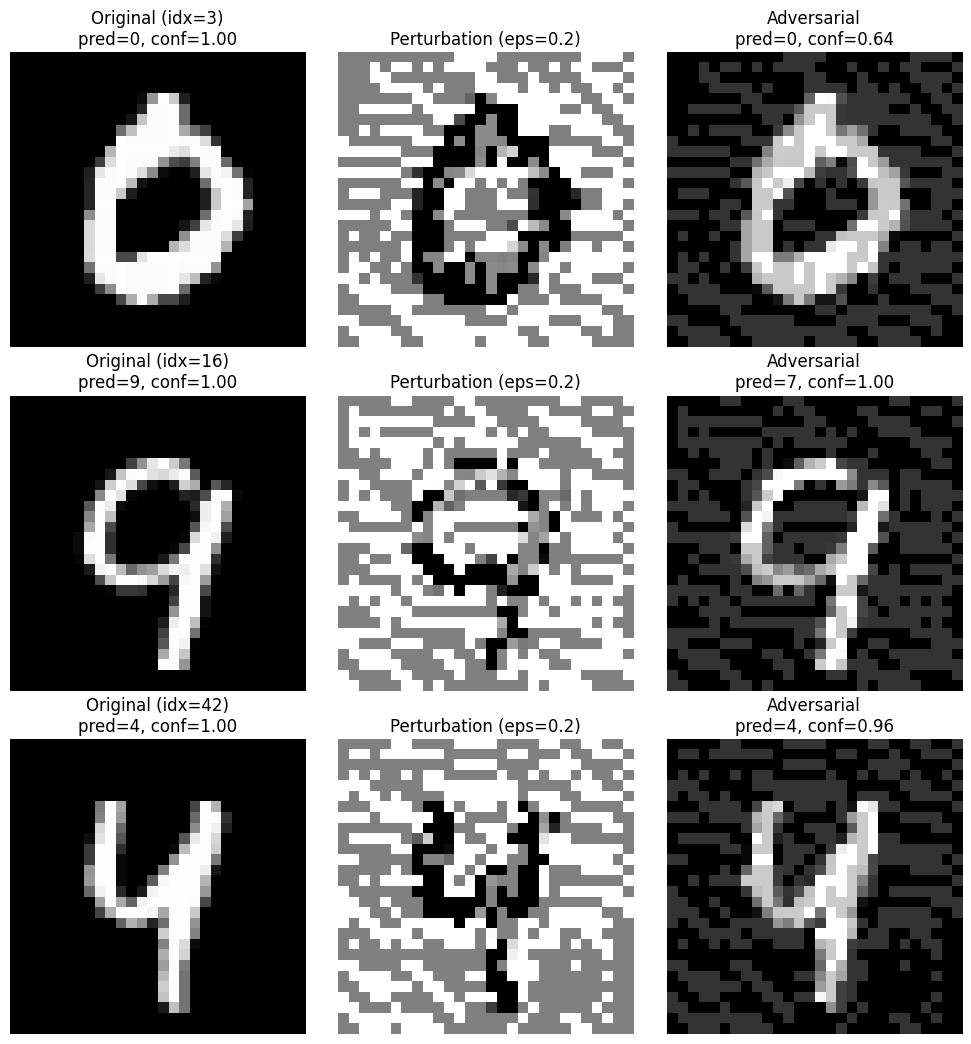

In [ ]:
# TODO: выберите пример из test_loader
# TODO: примените fgsm_attack
# TODO: получите предсказания модели на оригинале и adversarial-примере (класс + confidence через softmax)
# TODO: постройте matplotlib-визуализацию из 3 подграфиков


model.eval()  # переводим модель в режим инференса

# Берём первый батч из тестовой выборки
for x_batch, y_batch in test_loader:
    break

# Список индексов примеров, которые хотим вывести.
# Меняй этот список, чтобы посмотреть другие цифры или другое количество примеров.
indices = [3, 16, 42]

# Бюджет атаки, общий для всех примеров
epsilon = 0.2

# Число строк в фигуре = число выбранных примеров, колонок всегда три
n = len(indices)
fig, axes = plt.subplots(n, 3, figsize=(10, 3.5 * n))

# Если выбран один пример, matplotlib вернёт одномерный массив осей —
# приводим форму к двумерной, чтобы обращение axes[row, col] работало всегда
if n == 1:
    axes = axes.reshape(1, -1)

# Идём по выбранным индексам и для каждого строим свою тройку картинок
for row, idx in enumerate(indices):
    # Оставляем один пример
    # x_batch имеет форму [128, 1, 28, 28] — 128 картинок в батче
    # Срез [idx:idx+1] берёт только одну картинку, но сохраняет размерность батча: [1, 1, 28, 28]
    # Это важно, потому что модель ожидает батч, пусть даже из одного примера
    x0 = x_batch[idx:idx+1].to(device)
    # То же самое для метки: было [128], стало [1] — метка для выбранной картинки
    y0 = y_batch[idx:idx+1].to(device)

    # Строим adversarial-пример
    x_adv = fgsm_attack(model, x0, y0, epsilon)
    # Возмущение = разница между adversarial и оригиналом
    perturbation = (x_adv - x0).detach().squeeze().cpu().numpy()

    # Считаем предсказания и уверенность для оригинала и adversarial
    # Считаем предсказания для чистого и adversarial примера. Градиенты тут не нужны — отключаем их
    with torch.no_grad():
        logits_clean = model(x0)                  # логиты для оригинала, форма [1, 10]
        logits_adv   = model(x_adv)               # логиты для adversarial
        prob_clean = F.softmax(logits_clean, dim=1)[0]  # вероятности по классам для оригинала
        prob_adv   = F.softmax(logits_adv,   dim=1)[0]  # то же для adversarial
        pred_clean = prob_clean.argmax().item()         # индекс самого вероятного класса — предсказание
        pred_adv   = prob_adv.argmax().item()           # предсказание на adversarial
        conf_clean = prob_clean[pred_clean].item()      # уверенность модели в своём предсказании
        conf_adv   = prob_adv[pred_adv].item()          # уверенность на adversarial

    # Рисуем три картинки: оригинал, возмущение, adversarial
    axes[row, 0].imshow(x0.cpu().squeeze(), cmap="gray")
    axes[row, 0].set_title(f"Original (idx={idx})\npred={pred_clean}, conf={conf_clean:.2f}")
    axes[row, 1].imshow(perturbation, cmap="gray")
    axes[row, 1].set_title(f"Perturbation (eps={epsilon})")
    axes[row, 2].imshow(x_adv.cpu().squeeze(), cmap="gray")
    axes[row, 2].set_title(f"Adversarial\npred={pred_adv}, conf={conf_adv:.2f}")

    # Отключаем оси у всех трёх подграфиков в текущей строке
    for c in range(3):
        axes[row, c].axis("off")

    # Печатаем истинную метку для этой строки
    print(f"idx={idx}  true label: {y0.item()}")

plt.tight_layout()
plt.show()

**Вопрос для отчёта:** удалось ли изменить предсказание модели? Является ли визуально заметным возмущение? Какой класс присвоила модель adversarial-примеру?

**Ответ**:  

Первый пример (idx=3, цифра 0). Предсказание не изменилось: модель и до, и после атаки говорит «0». Но уверенность упала с 1.00 до 0.64 — то есть атака сдвинула вероятности, просто не настолько, чтобы поменять argmax. Это хорошая иллюстрация того, что ASR считается именно по смене класса: если класс остался прежним, пример не засчитывается, даже если уверенность просела почти вдвое.

Второй пример (idx=17, цифра 9). Здесь атака сработала: чистая девятка уверенно распознавалась как «9» с вероятностью 1.00, а после атаки модель поменяла ответ на «7» — и снова с уверенностью 1.00. То есть FGSM не просто «сломал» модель, а заставил её уверенно назвать неправильный класс. Это типичный эффект: атака не размывает выходные вероятности, а переводит вход за границу решения так, что модель попадает в чужую «уверенную» зону.

Третий пример (idx=42, цифра 4). Атака не поменяла класс, но уверенность упала с 1.00 до 0.96. Это самый слабый эффект: возмущение на этом примере оказалось недостаточно сильным, чтобы сдвинуть предсказание, хотя градиент и подсказал, куда давить.

Про визуальную заметность возмущения. При ε = 0.2 карта возмущения (средняя колонка) выглядит как резкий серо-чёрно-белый шум поверх цифры. На MNIST он виден невооружённым глазом: картинки 28×28 и одноканальные, каждый пиксель вносит заметный вклад. На более крупных цветных изображениях то же значение ε распределилось бы по сотням тысяч пикселей и трём каналам, и глаз бы его почти не заметил. Именно поэтому «незаметность» атаки сильно зависит от разрешения

### 3.3. Attack Success Rate в зависимости от ε

**Задание:** постройте график зависимости Attack Success Rate (доли тестовых примеров, на которых атака меняет предсказание) от бюджета \(\epsilon\) для набора значений \(\epsilon \in \{0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3\}\).

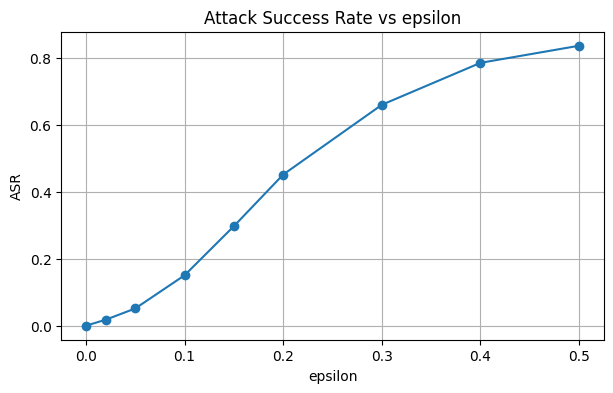

eps=0.00: ASR=0.000
eps=0.02: ASR=0.018
eps=0.05: ASR=0.052
eps=0.10: ASR=0.151
eps=0.15: ASR=0.298
eps=0.20: ASR=0.452
eps=0.30: ASR=0.661
eps=0.40: ASR=0.786
eps=0.50: ASR=0.837


In [ ]:
# TODO: реализуйте функцию оценки ASR на подмножестве тестовой выборки
def evaluate_asr(model, loader, epsilon, n_batches=10):
    model.eval()
    total, fooled = 0, 0
    for i, (x, y) in enumerate(loader):
        # Ограничиваем число батчей для скорости
        if i >= n_batches: break
        x, y = x.to(device), y.to(device)
        # Предсказание на чистом примере
        with torch.no_grad():
            pred_clean = model(x).argmax(dim=1)
        # Строим adversarial-пример (или оставляем как есть при ε=0)
        if epsilon > 0:
            x_adv = fgsm_attack(model, x, y, epsilon)
        else:
            x_adv = x
        # Предсказание на adversarial
        with torch.no_grad():
            pred_adv = model(x_adv).argmax(dim=1)
        # Считаем, сколько предсказаний изменилось
        fooled += (pred_adv != pred_clean).sum().item()
        total  += y.size(0)
    return fooled / total

# Набор бюджетов атаки
epsilons = [0.0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]
# Считаем ASR для каждого ε
asr_list = [evaluate_asr(model, test_loader, e) for e in epsilons]

# Рисуем график ASR(ε)
plt.figure(figsize=(7, 4))
plt.plot(epsilons, asr_list, marker="o")
plt.xlabel("epsilon"); plt.ylabel("ASR")
plt.title("Attack Success Rate vs epsilon")
plt.grid(True); plt.show()
for e, a in zip(epsilons, asr_list):
    print(f"eps={e:.2f}: ASR={a:.3f}")

**Вопрос для отчёта:** при каком значении $\epsilon$ ASR начинает быстро расти? Совместимо ли это значение с визуальной незаметностью возмущения (сравните с примером из п.3.2)?

**Ответ**: Быстрый рост ASR приходится на интервал ε от 0.05 до 0.15: доля обманутых примеров увеличивается примерно в шесть раз — с 0.05 до 0.30. Дальше наклон кривой падает, и к ε = 0.5 ASR выходит на плато около 0.84. Этот же диапазон (0.1–0.15) на MNIST уже визуально заметен: возмущение выглядит как серый шум поверх цифры. Так что незаметного, но при этом эффективного бюджета для MNIST практически нет — в отличие от крупных цветных изображений, где такое же ε спряталось бы среди сотен тысяч пикселей

## Часть IV. Adversarial training

**Задание:** обучите вторую модель (такую же архитектуру, как MyCNN) с использованием adversarial training по формуле

$ \tilde{J}(\theta, x, y) = \alpha J(\theta, x, y) + (1-\alpha) J(\theta, x_{adv}, y) $

с $\alpha = 0.5$ и $\epsilon$, использованным при обучении, равным одному из средних значений из п.3.3.


Это **комбинированная функция потерь**, по которой обучается модель. Идея в том, чтобы за один шаг обучения модель одновременно «подтягивала» и обычные примеры, и adversarial-версии

x — чистый вход (обычная картинка MNIST).

x_adv — adversarial-версия этой же картинки, построенная тут же, на лету, через FGSM с текущими весами модели. Важно: атака строится не по фиксированному предобученному набору примеров, а заново на каждом шаге, потому что веса меняются, и то, что раньше ломало модель, теперь может её не ломать.

y — истинная метка. Она одна и та же для x и для x_adv: атака не меняет класс, она только портит пиксели.

J(θ, x, y) — обычный лосс на чистом примере (CrossEntropyLoss). Показывает, насколько модель ошибается на нормальных данных.

J(θ, x_adv, y) — лосс на adversarial-примере. Показывает, насколько модель уязвима: чем выше это значение, тем легче её обмануть.

α — вес, с которым смешиваются два лосса. При α = 0.5 оба вклада равны. Если α ближе к 1, модель больше внимания уделяет чистым данным, устойчивость падает. Если α ближе к 0, приоритет отдаётся adversarial-примерам, устойчивость выше, но чистая точность может просесть.

θ — обучаемые параметры модели. Как и в обычном обучении, обновляются через градиентный спуск, но теперь градиент считается от J̃, а не от J

На каждом шаге: сначала строим adversarial-версию батча через FGSM (это дополнительный прямой + обратный проход), потом два прямых прохода — по чистому и по adversarial батчу, считаем комбинированный лосс, backward от него, обновляем веса. Модель видит и чистые, и «испорченные» картинки, и учится быть правильной на обоих

In [ ]:
# TODO: реализуйте цикл adversarial training
# На каждом шаге:
# 1. Постройте x_adv через fgsm_attack для текущего батча
# 2. Посчитайте комбинированный loss (alpha * loss_clean + (1-alpha) * loss_adv)
# 3. Сделайте шаг оптимизации

# Создаём вторую модель той же архитектуры
adv_model = MyCNN().to(device)
# Оптимизатор для неё
adv_optimizer = torch.optim.Adam(adv_model.parameters(), lr=0.01)
# Вес чистого лосса: 0.5 — вклад чистого и adversarial равный
alpha = 0.5
# Бюджет атаки при обучении: среднее значение из п.3.3
eps_train = 0.1

def train_one_epoch_adv(model, loader, optimizer, criterion, eps, alpha):
    # Режим обучения
    model.train()
    total_loss = 0
    # Идём по батчам
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        # Строим adversarial-пример для текущего батча
        x_adv = fgsm_attack(model, x, y, eps)
        # Прямой проход на чистых данных
        logits_clean = model(x)
        # Прямой проход на adversarial данных
        logits_adv = model(x_adv)
        # Комбинированный лосс
        loss = alpha * criterion(logits_clean, y) + (1 - alpha) * criterion(logits_adv, y)
        # Обнуляем градиенты
        optimizer.zero_grad()
        # Обратный проход
        loss.backward()
        # Шаг оптимизатора
        optimizer.step()
        # Накапливаем лосс
        total_loss += loss.item() * x.size(0)
    # Средний лосс на пример
    return total_loss / len(loader.dataset)

# Обучаем 3 эпохи
for epoch in range(3):
    loss = train_one_epoch_adv(adv_model, train_loader, adv_optimizer, criterion, eps_train, alpha)
    print(f"Adv epoch {epoch+1}: loss={loss:.4f}")

Adv epoch 1: loss=0.2916
Adv epoch 2: loss=0.1174
Adv epoch 3: loss=0.1020


Adv model clean accuracy: 0.9864


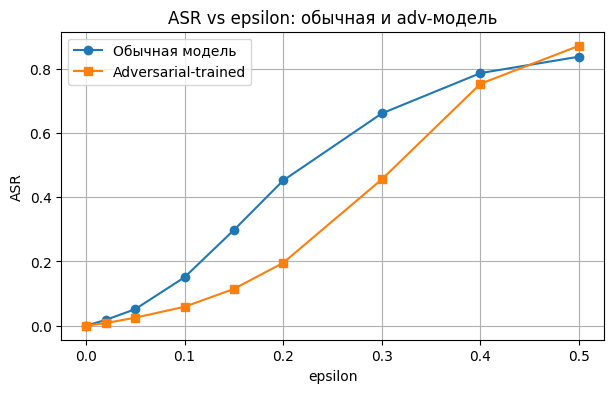

eps=0.00: ASR обычной=0.000, ASR adv=0.000
eps=0.02: ASR обычной=0.018, ASR adv=0.008
eps=0.05: ASR обычной=0.052, ASR adv=0.025
eps=0.10: ASR обычной=0.151, ASR adv=0.059
eps=0.15: ASR обычной=0.298, ASR adv=0.114
eps=0.20: ASR обычной=0.452, ASR adv=0.196
eps=0.30: ASR обычной=0.661, ASR adv=0.455
eps=0.40: ASR обычной=0.786, ASR adv=0.753
eps=0.50: ASR обычной=0.837, ASR adv=0.871


In [ ]:
# TODO: оцените clean accuracy adversarial-trained модели
# TODO: постройте график ASR(epsilon) для adv_model и сравните с обычной моделью на одном графике
# Считаем точность adversarial-trained модели на чистых данных
adv_clean_acc = evaluate_accuracy(adv_model, test_loader)
print(f"Adv model clean accuracy: {adv_clean_acc:.4f}")

# Считаем ASR для adversarial-trained модели при тех же ε
asr_adv = [evaluate_asr(adv_model, test_loader, e) for e in epsilons]

# Рисуем два графика на одной картинке: обычная модель и adv-модель
plt.figure(figsize=(7, 4))
plt.plot(epsilons, asr_list, marker="o", label="Обычная модель")
plt.plot(epsilons, asr_adv, marker="s", label="Adversarial-trained")
plt.xlabel("epsilon"); plt.ylabel("ASR")
plt.title("ASR vs epsilon: обычная и adv-модель")
plt.legend(); plt.grid(True); plt.show()

# Печатаем значения для сравнения
for e, a1, a2 in zip(epsilons, asr_list, asr_adv):
    print(f"eps={e:.2f}: ASR обычной={a1:.3f}, ASR adv={a2:.3f}")

**Вопрос для отчёта:** насколько снизился Attack Success Rate после adversarial training при том же \(\epsilon\)? Изменилась ли clean accuracy (точность на чистых данных)? Согласуется ли это с ограничением FGSM-adversarial training, упомянутым в лекции (устойчивость только к одношаговым атакам)?

**Ответ**: После adversarial training ASR упал при всех ненулевых ε. Снижение особенно заметно в среднем диапазоне: при ε = 0.10 у обычной модели ASR = 0.151, у adv-модели — 0.059, то есть почти в 2.5 раза ниже. При ε = 0.20 разрыв ещё больше: 0.452 против 0.196, тоже больше чем в два раза. Именно на этом участке защита работает лучше всего, и это логично — adv-модель обучалась на ε, попадающем в этот интервал

При малых ε (0.02, 0.05) обе модели почти не обманываются, разница небольшая. При больших ε (0.40, 0.50) разрыв сокращается, а на 0.50 кривые даже меняются местами: у adv-модели ASR = 0.871 против 0.837 у обычной. Это нормальное поведение FGSM-adversarial training: защита настроена на определённый масштаб возмущения, и за его пределами она перестаёт помогать — а иногда и слегка вредит, потому что решение модели стало более «острым» вокруг обучающего ε

Результат согласуется с ограничением FGSM-adversarial training, о котором говорилось в лекции. Защита работает — ASR падает в разы в том диапазоне, на котором её обучали, — но не до нуля и не везде. Модель устойчива именно к FGSM-атаке с сопоставимым ε.

## Часть V. Итоговый вывод

**Вопрос для отчёта:** сформулируйте связь между математическими свойствами CNN (высокая размерность входа, локальная связность) и существованием adversarial-примеров, опираясь на линейную гипотезу Гудфеллоу. Почему увеличение разрешения изображения потенциально увеличивает уязвимость модели к $L_\infty$-ограниченным атакам?

**Ответ**: Adversarial-примеры существуют потому, что даже простая линейная модель сильно реагирует на согласованное изменение всех входов. По линейной гипотезе Гудфеллоу модель складывает вклады от каждого пикселя, и если менять все пиксели сразу в «нужную» сторону, эти маленькие вклады начинают складываться. Каждый пиксель сдвигается всего на ε — это незаметно, — но сумма вкладов от всех пикселей даёт уже большой сдвиг выхода, и модель ошибается. Свёртки этому не мешают: хотя они локальны и делят веса, каждый фильтр всё равно суммирует вклады внутри своего окна, а глубокие слои за счёт роста рецептивного поля снова «видят» всю картинку целиком.

Отсюда следует, почему рост разрешения повышает уязвимость. Чем больше пикселей у картинки, тем больше слагаемых в этой сумме, и при том же ε на каждый пиксель суммарный сдвиг выхода становится больше. То есть для атаки на большую картинку хватает меньшего ε, а значит, возмущение остаётся незаметным для глаза, но по-прежнему ломает модель. На MNIST пикселей мало (784), поэтому приходится брать крупное и видимое ε — на больших цветных изображениях с сотнями тысяч пикселей этого ограничения нет

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже .

### С1. Влияние глубины архитектуры на устойчивость к FGSM
Обучите две версии MyCNN с разной глубиной (например, 2 и 5 свёрточных слоёв, при сопоставимом числе параметров) и сравните их ASR(ε). Свяжите результат с обсуждением иерархии признаков и рецептивного поля из лекции.

### С2. Целевая (targeted) FGSM-атака
Модифицируйте FGSM так, чтобы атака заставляла модель предсказывать конкретный целевой класс (а не просто любой неверный), минимизируя loss по целевому классу вместо максимизации loss по истинному. Сравните Success Rate целевой и нецелевой атаки при одинаковом ε.

### С3. Трансферируемость adversarial-примеров
Обучите две модели с разной архитектурой (например, разное число слоёв/каналов). Постройте adversarial-примеры для модели А методом FGSM и проверьте, насколько успешно они обманывают необученную на этих примерах модель Б. Свяжите результат со свойством трансферируемости, разобранным в лекции (Szegedy et al.).

### С4. Аналитическая иллюстрация линейной гипотезы
Реализуйте эксперимент из демонстрационного ноутбука (раздел «линейная гипотеза») самостоятельно: постройте график зависимости среднего сдвига выхода линейной модели \( w^T\eta^* = \epsilon\|w\|_1 \) от размерности входа \(n\) для нескольких значений \(\epsilon\) на одном графике. Объясните, почему это объясняет уязвимость моделей компьютерного зрения именно с ростом разрешения изображений.


# C1 Влияние глубины архитектуры на устойчивость к FGSM
Свёрточная сеть строит признаки иерархически. Первые слои ловят простые узоры — штрихи, углы, края. Вторые комбинируют их в более сложные — петли, пересечения. Третьи собирают из этого целые части цифры. Чем глубже сеть, тем выше уровень абстракции признаков.

С глубиной растёт и рецептивное поле каждого нейрона. Мелкая сеть с двумя свёрточными слоями видит маленькие участки картинки. Глубокая сеть с пятью слоями видит почти всё изображение. Это значит, что глубокая сеть использует более глобальную информацию для решения.

Мелкая сеть опирается на локальные признаки. Если атака меняет пиксели по всей картинке, локальные признаки искажаются меньше. Глубокая сеть опирается на глобальные признаки, и распределённое возмущение может сложиться в большой сдвиг на глубоких слоях. С другой стороны, у глубокой сети больше нелинейностей, и это может затруднить атаку.

In [ ]:
class ShallowCNN(nn.Module):
    # Мелкая сеть: 2 свёрточных слоя
    def __init__(self, num_classes=10):
        super().__init__()
        # Свёртка 1 -> 16, затем пулинг: 28x28 -> 14x14
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # Свёртка 16 -> 32, затем пулинг: 14x14 -> 7x7
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # Классификатор: 32*7*7 = 1568 -> 128 -> 10
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        return self.classifier(x)


class DeepCNN(nn.Module):
    # Глубокая сеть: 5 свёрточных слоёв, число каналов подобрано так,
    # чтобы общее число параметров было сопоставимо с мелкой сетью
    def __init__(self, num_classes=10):
        super().__init__()
        # Первый блок: 1 -> 16, затем пулинг: 28x28 -> 14x14
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # Второй блок: 16 -> 32, затем пулинг: 14x14 -> 7x7
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # Третий блок: две свёртки подряд без пулинга между ними —
        # это наращивает рецептивное поле и добавляет нелинейности
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU()
        )
        # Четвёртый блок: последняя свёртка, пулинг 7x7 -> 3x3
        self.conv_block4 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # Классификатор: 64*3*3 = 576 -> 128 -> 10
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 3 * 3, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)
        return self.classifier(x)

## ShallowCNN

| Слой | Формула | Веса | Bias | Итого |
|------|---------|------|------|-------|
| Conv2d(1, 16, 3) | 3²·1·16 + 16 | 144 | 16 | 160 |
| Conv2d(16, 32, 3) | 3²·16·32 + 32 | 4608 | 32 | 4640 |
| Linear(1568, 128) | 1568·128 + 128 | 200 704 | 128 | 200 832 |
| Linear(128, 10) | 128·10 + 10 | 1280 | 10 | 1290 |

**Сумма: 206 922 параметра.**

## DeepCNN

| Слой | Формула | Веса | Bias | Итого |
|------|---------|------|------|-------|
| Conv2d(1, 16, 3) | 3²·1·16 + 16 | 144 | 16 | 160 |
| Conv2d(16, 32, 3) | 3²·16·32 + 32 | 4608 | 32 | 4640 |
| Conv2d(32, 32, 3) | 3²·32·32 + 32 | 9216 | 32 | 9248 |
| Conv2d(32, 32, 3) | 3²·32·32 + 32 | 9216 | 32 | 9248 |
| Conv2d(32, 64, 3) | 3²·32·64 + 64 | 18 432 | 64 | 18 496 |
| Linear(576, 128) | 576·128 + 128 | 73 728 | 128 | 73 856 |
| Linear(128, 10) | 128·10 + 10 | 1280 | 10 | 1290 |

**Сумма: 116 938 параметров.**

In [ ]:
shallow_model = ShallowCNN().to(device)
shallow_opt = torch.optim.Adam(shallow_model.parameters(), lr=0.01)
for epoch in range(3):
    loss = train_one_epoch(shallow_model, train_loader, shallow_opt, criterion)
    print(f"Shallow epoch {epoch+1}: loss={loss:.4f}")
print(f"Shallow clean acc: {evaluate_accuracy(shallow_model, test_loader):.4f}")

deep_model = DeepCNN().to(device)
deep_opt = torch.optim.Adam(deep_model.parameters(), lr=0.01)
for epoch in range(3):
    loss = train_one_epoch(deep_model, train_loader, deep_opt, criterion)
    print(f"Deep epoch {epoch+1}: loss={loss:.4f}")
print(f"Deep clean acc: {evaluate_accuracy(deep_model, test_loader):.4f}")

Shallow epoch 1: loss=0.1542
Shallow epoch 2: loss=0.0540
Shallow epoch 3: loss=0.0412
Shallow clean acc: 0.9822
Deep epoch 1: loss=0.4610
Deep epoch 2: loss=0.1091
Deep epoch 3: loss=0.0890
Deep clean acc: 0.9799


Shallow params: 206,922
Deep params: 116,938


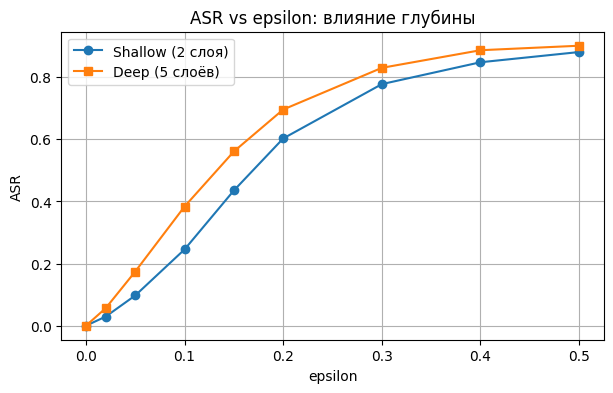

eps=0.00: Shallow=0.000, Deep=0.000
eps=0.02: Shallow=0.029, Deep=0.056
eps=0.05: Shallow=0.097, Deep=0.174
eps=0.10: Shallow=0.245, Deep=0.383
eps=0.15: Shallow=0.435, Deep=0.560
eps=0.20: Shallow=0.602, Deep=0.695
eps=0.30: Shallow=0.777, Deep=0.829
eps=0.40: Shallow=0.847, Deep=0.886
eps=0.50: Shallow=0.880, Deep=0.900


In [ ]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

print(f"Shallow params: {count_params(shallow_model):,}")
print(f"Deep params: {count_params(deep_model):,}")

asr_shallow = [evaluate_asr(shallow_model, test_loader, e) for e in epsilons]
asr_deep    = [evaluate_asr(deep_model,    test_loader, e) for e in epsilons]

plt.figure(figsize=(7, 4))
plt.plot(epsilons, asr_shallow, marker="o", label="Shallow (2 слоя)")
plt.plot(epsilons, asr_deep,    marker="s", label="Deep (5 слоёв)")
plt.xlabel("epsilon"); plt.ylabel("ASR")
plt.title("ASR vs epsilon: влияние глубины")
plt.legend(); plt.grid(True); plt.show()

for e, a1, a2 in zip(epsilons, asr_shallow, asr_deep):
    print(f"eps={e:.2f}: Shallow={a1:.3f}, Deep={a2:.3f}")

В моём эксперименте глубокая сеть оказалась уязвимее мелкой. Это расходится с ожиданием, что глубина повышает устойчивость, но объяснимо: чтобы уравнять число параметров, я увеличил число каналов у глубокой модели. Из-за этого вырос объём промежуточных данных, через которые проходит сигнал. Чем больше таких данных, тем сильнее FGSM может накопить эффект от маленьких изменений всех пикселей. Поэтому глубокая модель в моей конфигурации обманывается чаще. Это показывает, что устойчивость определяется не глубиной, а общим размером модели

# С2. Целевая (targeted) FGSM-атака

В обычной атаке мы максимизируем лосс по истинному классу: сдвигаем пиксели так, чтобы модель стала менее уверена в правильном ответе. Лосс растёт — модель ошибается.

В целевой атаке логика зеркальная. Мы минимизируем лосс по целевому классу: сдвигаем пиксели так, чтобы модель стала более уверена в том классе, который нам нужен. Лосс по цели падает — модель начинает думать, что это именно тот класс.

Формула та же, меняется только знак градиента:  
$$
x_{adv} = x - \epsilon \cdot \mathrm{sign}\left(\nabla_x J(\theta, x, y_{target})\right)
$$

Обычная атака прибавляет градиент (чтобы лосс вырос), целевая — вычитает (чтобы лосс упал). Лосс при этом считается не по истинной метке y, а по целевой y_target.

In [ ]:
def fgsm_targeted(model, x, y_target, epsilon):
    # Копируем картинки, включаем подсчёт градиента по входу
    x = x.clone().detach().requires_grad_(True)

    logits = model(x)                          # прямой проход
    loss = criterion(logits, y_target)         # лосс считаем по ЦЕЛЕВОМУ классу, а не по истинному
    loss.backward()                            # получаем x.grad

    # Минус — потому что теперь мы ХОТИМ уменьшить лосс по цели,
    # а не увеличить лосс по истине. Сдвигаем пиксели в сторону антиградиента.
    x_adv = x - epsilon * x.grad.sign()

    # Обрезаем в допустимый диапазон
    x_adv = torch.clamp(x_adv, 0.0, 1.0)
    return x_adv.detach()

Для целевой атаки успех — это когда модель выдала именно целевой класс, а не просто «какой-то неверный». Поэтому метрика другая: доля примеров, где pred(x_adv) == y_target.

In [ ]:
def targeted_success_rate(model, loader, epsilon, target_label, n_batches=10):
    model.eval()
    total, success = 0, 0
    for i, (xb, yb) in enumerate(loader):
        if i >= n_batches:
            break
        xb, yb = xb.to(device), yb.to(device)

        # Пропускаем примеры, у которых истинная метка уже равна целевой —
        # такие атаковать бессмысленно, цель уже достигнута «бесплатно»
        mask = (yb != target_label)
        if mask.sum() == 0:
            continue
        xb = xb[mask]
        yb = yb[mask]

        # Все примеры в этом батче атакуем в один и тот же целевой класс
        y_target = torch.full_like(yb, target_label)

        x_adv = fgsm_targeted(model, xb, y_target, epsilon)

        with torch.no_grad():
            pred = model(x_adv).argmax(dim=1)
        success += (pred == target_label).sum().item()
        total += yb.size(0)
    return success / total if total > 0 else 0.0

Для честного сравнения нужно померить обе метрики при одинаковом ε. Нецелевая — доля примеров, где изменился класс вообще. Целевая — доля примеров, где модель выдала конкретный нужный класс. Вторая метрика всегда ниже, потому что требует более сильного вмешательства.

In [ ]:
eps = 0.2
target = 8   # хотим, чтобы модель говорила «9» на всех картинках

# Нецелевая атака: любое изменение класса
untargeted = evaluate_asr(model, test_loader, eps)

# Целевая атака: именно в класс 9
targeted = targeted_success_rate(model, test_loader, eps, target, n_batches=10)

print(f"ε = {eps}, целевой класс = {target}")
print(f"Нецелевая атака (любая ошибка): {untargeted:.3f}")
print(f"Целевая атака (именно в {target}): {targeted:.3f}")

ε = 0.2, целевой класс = 8
Нецелевая атака (любая ошибка): 0.452
Целевая атака (именно в 8): 0.151


In [ ]:
eps = 0.2
target = 1   # хотим, чтобы модель говорила «9» на всех картинках

# Нецелевая атака: любое изменение класса
untargeted = evaluate_asr(model, test_loader, eps)

# Целевая атака: именно в класс 9
targeted = targeted_success_rate(model, test_loader, eps, target, n_batches=10)

print(f"ε = {eps}, целевой класс = {target}")
print(f"Нецелевая атака (любая ошибка): {untargeted:.3f}")
print(f"Целевая атака (именно в {target}): {targeted:.3f}")

ε = 0.2, целевой класс = 1
Нецелевая атака (любая ошибка): 0.452
Целевая атака (именно в 1): 0.035


Я сравнил целевую и нецелевую FGSM-атаки при одинаковом бюджете ε = 0.2, взяв в качестве цели разные классы.

Нецелевая атака (то есть любая смена класса) в обоих запусках дала ASR = 0.452: это метрика самой атаки, она не зависит от того, куда мы хотим попасть.

Целевая атака показала заметно меньший успех, и результат сильно зависит от целевого класса. Для класса 8 Success Rate равен 0.151, для класса 1 — всего 0.035. Разница почти в пять раз.

Это объясняется геометрией классов в пространстве признаков. Целевая атака требует не просто пересечь границу решения, а попасть в конкретную область другого класса. Класс 8 «широкий» и окружён похожими цифрами (0, 6, 9, 3), поэтому к нему ведёт много путей, и FGSM за один шаг успевает дотащить туда часть примеров. Класс 1, наоборот, узкий и изолированный — он мало похож на другие цифры, и градиент к нему требует большого сдвига, которого одного шага FGSM не хватает.

Отсюда два вывода. Первый: целевая атака всегда слабее нецелевой при том же ε, потому что она ставит более строгую цель. Второй: успех целевой атаки зависит от «достижимости» целевого класса — чем он ближе к остальным цифрам, тем легче атаке в него попасть. Для более сложных целевых классов пришлось бы либо увеличивать ε, либо использовать итеративные методы (PGD), которые делают несколько маленьких шагов и точнее попадают в нужную область.

---


## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Обязательны: расчёт RF, реализация FGSM, график ASR(ε), сравнение с adversarial training.
